# Student Submission

Fill in your IDs before submitting.

| | ID |
|---|----|
| Eyal Perets | 209541903 |
| Dylan Lewis | 209722610 |

# Tabular RL in MiniGrid: HW2 Template (2026 B)

## Overview
You will solve **two custom MiniGrid environments** using **tabular** reinforcement learning,
implementing **Monte Carlo (MC)**, **SARSA**, and **Q-Learning** from scratch — no external RL
libraries, no deep learning.

**Read the accompanying PDF first.** This notebook defines the environment APIs and the points
where you may edit; the PDF defines what to deliver and how it is graded. The **report** is the
primary deliverable and must be fully self-contained: every graph, table, numerical result, and
discussion point lives there.

## Learning objectives
- Model each environment as an MDP and pick a state representation that fits.
- Implement MC, SARSA, and Q-Learning yourself, and reason about when each one helps or hurts.
- Choose hyperparameters and an exploration strategy deliberately, and explain the choices.
- Communicate training and inference results with clear plots, tables, and video clips.

## Deliverables & submission
Submit (1) a Colab link to this notebook with all training and inference outputs, and (2) the report
`report_ID1_ID2.pdf`. A reader should be able to understand your full methodology and all of your
results from the report alone. See the PDF for the exact submission instructions.

# Setup

## Installs

In [228]:
# Auto-install any missing dependencies. Idempotent: pip is only invoked
# for packages that aren't already importable, so re-running this cell is
# safe and cheap on both Colab and a local Python / venv kernel.
import importlib
import subprocess
import sys


def _pip_install(*packages: str) -> None:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "--quiet", *packages]
    )


def _ensure(import_name: str, pip_name: str | None = None) -> None:
    try:
        importlib.import_module(import_name)
    except ImportError:
        _pip_install(pip_name or import_name)


_ensure("gymnasium")
_ensure("minigrid")
_ensure("imageio")
_ensure("imageio_ffmpeg", "imageio[ffmpeg]")  # mp4 backend
_ensure("numpy")
_ensure("matplotlib")
_ensure("tqdm")

# pyvirtualdisplay is only useful on a headless Linux host (e.g. Colab).
if "google.colab" in sys.modules or sys.platform.startswith("linux"):
    _ensure("pyvirtualdisplay")

## Imports

In [229]:
from __future__ import annotations

# Standard library
import base64
import os
import random
import sys
from abc import ABC, abstractmethod
from collections import defaultdict
from typing import TypeAlias

# Numerics, plotting, video, progress bars
import numpy as np
import matplotlib.pyplot as plt
import imageio
from tqdm.auto import tqdm

# Notebook display helpers
import IPython
from IPython.display import HTML

# Gymnasium + MiniGrid (environment framework)
import gymnasium as gym
from gymnasium import spaces
from minigrid.core.grid import Grid
from minigrid.core.mission import MissionSpace
from minigrid.core.world_object import Door, Goal, Key, Lava, Wall
from minigrid.minigrid_env import MiniGridEnv as BaseMiniGridEnv

%matplotlib inline
plt.rcParams["figure.figsize"] = (8.0, 6.0)

# Display utils
The helpers below let you save a rollout to an `.mp4` file and embed it inline in the notebook. They
auto-detect whether the notebook is running on **Google Colab** or on a **local Jupyter** kernel and
adapt accordingly; no configuration needed.

In [230]:
# Auto-detect the runtime so the same notebook works on Colab and locally.
IN_COLAB = "google.colab" in sys.modules

# On headless Linux (e.g. Colab) MiniGrid's renderer needs a virtual display.
# On Windows/macOS local Jupyter, pyvirtualdisplay is unavailable and unneeded
# — `env.render()` returns an RGB array without an X server.
_virtual_display = None
if IN_COLAB:
    try:
        import pyvirtualdisplay
        _virtual_display = pyvirtualdisplay.Display(visible=0, size=(1400, 900)).start()
    except Exception as exc:  # pragma: no cover
        print(f"[display utils] virtual display not started: {exc}")


def video_path(name: str, folder_name: str = "videos") -> str:
    """Return a writable absolute path for a video file under ``folder_name/``."""
    folder = os.path.join(os.getcwd(), folder_name)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)

def plot_image_path(name: str, folder_name: str = "plots") -> str:
    """Return a writable absolute path for an image file under ``folder_name/``."""
    folder = os.path.join(os.getcwd(), folder_name)
    os.makedirs(folder, exist_ok=True)
    return os.path.join(folder, name)


def embed_mp4(filename: str):
    """Embed an mp4 file inline. Works in Colab and local Jupyter alike."""
    with open(filename, "rb") as f:
        b64 = base64.b64encode(f.read()).decode()
    tag = (
        '<video width="640" height="480" controls>'
        f'<source src="data:video/mp4;base64,{b64}" type="video/mp4">'
        "Your browser does not support the video tag."
        "</video>"
    )
    return HTML(tag)


def random_rollout_video(env, filename: str, max_steps: int = 100, fps: int = 10, seed: int | None = None):
    """Run one random-action episode and save it as mp4. Returns (steps, total_reward)."""
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)
    env.reset(seed=seed)
    total_reward = 0.0
    steps = 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = random.randint(0, env.action_space.n - 1)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            video.append_data(env.render())
            if terminated or truncated:
                break
    return steps, total_reward

# Environments

Two custom MiniGrid environments are defined below: **`EmptyEnv`** and **`KeyDoorLavaEnv`**. Both
expose all 7 MiniGrid actions and use a sparse reward (`+1` on goal, `0` otherwise). Each env's
section below explains the layout and the rules on what you may edit.

**Action IDs.** Both envs use the standard MiniGrid action space (`Discrete(7)`):

| ID | Name | Effect |
|---|---|---|
| 0 | `left` | turn 90° to the left (no move) |
| 1 | `right` | turn 90° to the right (no move) |
| 2 | `forward` | move one cell in the facing direction |
| 3 | `pickup` | pick up an object in the cell directly in front |
| 4 | `drop` | drop the carried object into the cell directly in front |
| 5 | `toggle` | activate the object in front (e.g. open a door with the matching key) |
| 6 | `done` | no-op in these envs |

**Coordinates.** Cells are `(x, y)` with `x` growing **rightward** and `y` growing **downward**
(so `y=1` is the top interior row and `y=H-2` is the bottom). The agent's facing direction
`env.agent_dir` is `0` = right, `1` = down, `2` = left, `3` = up.

In [231]:
# =============================================================================
# ENVIRONMENT 1: EmptyEnv
# =============================================================================
from typing import Callable, Optional


class EmptyEnv(BaseMiniGridEnv):
    """Empty N×M room. Random agent start/direction, goal at (W-2, H-2).
    Sparse reward: +1 on goal, 0 otherwise.

    The action space exposes all 7 MiniGrid actions. You decide which ones
    your policy actually uses. Once you pick a subset for a run, keep it
    fixed for the whole run. (For example: does this env need `pickup`?)
    """

    def __init__(
        self,
        width: int = 10,
        height: int = 10,
        max_steps: int = 256,
        render_mode: str = "rgb_array",
        **kwargs,
    ):
        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space,
            width=width,
            height=height,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )
        self.action_space = spaces.Discrete(7)
        self.goal_pos = (width - 2, height - 2)

    @staticmethod
    def _gen_mission():
        return "reach the goal"

    def _gen_grid(self, width: int, height: int):
        # Called by the base class's reset() at the start of every episode;
        # this method (re)builds the grid and randomises agent placement.

        # outer wall
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # goal fixed in the bottom-right corner
        self.goal_pos = (width - 2, height - 2)
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # random agent start (any interior cell except the goal) + random facing
        while True:
            ax = int(self.np_random.integers(1, width - 1))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != self.goal_pos:
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        self.mission = "reach the goal"

    def step(self, action):
        obs, _, terminated, truncated, info = super().step(action)
        reward = 50. if terminated else -0.1  # you may scale this value
        
        return obs, reward, terminated, truncated, info


In [232]:
# =============================================================================
# ENVIRONMENT 2: KeyDoorLavaEnv
# =============================================================================
class KeyDoorLavaEnv(BaseMiniGridEnv):
    """Two-room N×M grid: left room with a key, partition wall with a
    locked door, right room with a vertical lava column (safe gap rows)
    and a goal at one of the two right-room corners.

    Sparse reward: +1 on reaching the goal, 0 otherwise. Stepping on lava
    terminates the episode with reward 0.

    The action space exposes all 7 MiniGrid actions. Pick the subset your
    policy actually uses for an experiment and keep that subset fixed for
    the whole run. Don't, e.g., disable `pickup` mid-episode once the key
    is in hand.

    Helper methods (use them in your state representation and in reward
    shaping):
      is_carrying_key(), is_door_open(), has_crossed_lava(),
      is_on_lava(), current_key_pos().
    """

    def __init__(
        self,
        width: int = 10,
        height: int = 10,
        max_steps: int = 512,
        partition_col: int = 4,
        lava_col: int = 7,
        lava_gap_rows: tuple[int, ...] = (4, 5),
        key_color: str = "yellow",
        render_mode: str = "rgb_array",
        **kwargs,
    ):
        # geometry sanity (consolidated)
        assert width >= 5 and height >= 5
        assert 2 <= partition_col < lava_col < width - 1
        assert len(lava_gap_rows) >= 1
        assert all(1 <= ly <= height - 2 for ly in lava_gap_rows)

        mission_space = MissionSpace(mission_func=self._gen_mission)
        super().__init__(
            mission_space=mission_space,
            width=width,
            height=height,
            see_through_walls=True,
            max_steps=max_steps,
            render_mode=render_mode,
            highlight=False,
            **kwargs,
        )
        self.action_space = spaces.Discrete(7)
        self.partition_col = partition_col
        self.lava_col = lava_col
        self.lava_gap_rows = list(lava_gap_rows)
        self.key_color = key_color  # matching color used for both Key and Door
        self._door = None
        self._key = None
        self._key_pos: tuple[int, int] | None = None
        self.door_pos: tuple[int, int] | None = None
        self.goal_pos: tuple[int, int] | None = None
        self.lava_positions: list[tuple[int, int]] = []
        # --------- TODO (student): reward-shaping setup ----------------------
        # If your shaping needs any setup, do it here.
        
        # ---------------------------------------------------------------------

    @staticmethod
    def _gen_mission():
        return "pick up the key, open the door, cross the lava gap, reach the goal"

    def _gen_grid(self, width: int, height: int):
        # Called by the base class's reset() at the start of every episode;
        # this method (re)builds the grid and randomises door / key / goal /
        # agent placement.

        # outer wall
        self.grid = Grid(width, height)
        self.grid.wall_rect(0, 0, width, height)

        # partition wall splitting the room into left/right halves
        for y in range(height):
            self.grid.set(self.partition_col, y, Wall())

        # locked door at a random row of the partition
        door_y = int(self.np_random.integers(1, height - 1))
        self.door_pos = (self.partition_col, door_y)
        self._door = Door(self.key_color, is_locked=True)
        self.grid.set(self.partition_col, door_y, self._door)

        # single key at a random interior cell of the left room
        key_x = int(self.np_random.integers(1, self.partition_col))
        key_y = int(self.np_random.integers(1, height - 1))
        self._key = Key(self.key_color)
        self.grid.set(key_x, key_y, self._key)
        self._key_pos = (key_x, key_y)

        # vertical lava column in the right room, with safe gap rows
        self.lava_positions = []
        for ly in range(1, height - 1):
            if ly in self.lava_gap_rows:
                continue
            self.grid.set(self.lava_col, ly, Lava())
            self.lava_positions.append((self.lava_col, ly))

        # goal in one of the two right-room corners (past the lava column)
        goal_y = int(self.np_random.choice([1, height - 2]))
        self.goal_pos = (width - 2, goal_y)
        self.put_obj(Goal(), self.goal_pos[0], self.goal_pos[1])

        # random agent start in the left room (never on the key) + random facing
        while True:
            ax = int(self.np_random.integers(1, self.partition_col))
            ay = int(self.np_random.integers(1, height - 1))
            if (ax, ay) != (key_x, key_y):
                break
        self.agent_pos = (ax, ay)
        self.agent_dir = int(self.np_random.integers(0, 4))

        self.mission = self._gen_mission()

    def reset(self, *, seed=None, options=None):
        # The base class's reset() calls _gen_grid() for us; this override
        # exists only to expose a hook for any per-episode shaping setup.
        obs, info = super().reset(seed=seed, options=options)
        # --------- TODO (student): reward-shaping setup ----------------------
        # Reset anything your shaping needs to start fresh.
        # ---------------------------------------------------------------------
        self.first_time_carry_key = True
        self.first_time_open_door = True
        return obs, info

    # ------------------------------------------------------------------ helpers
    def is_carrying_key(self) -> bool:
        return isinstance(self.carrying, Key)

    def is_door_open(self) -> bool:
        return bool(self._door is not None and self._door.is_open)

    def has_crossed_lava(self) -> bool:
        return int(self.agent_pos[0]) > self.lava_col

    def is_on_lava(self) -> bool:
        return tuple(self.agent_pos) in set(self.lava_positions)

    def current_key_pos(self) -> tuple[int, int] | None:
        """Return the key's (x, y) cell, or None if the agent is currently carrying it."""
        if self.is_carrying_key():
            return None
        if self._key_pos is not None:
            x, y = self._key_pos
            if isinstance(self.grid.get(x, y), Key):
                return self._key_pos
        # cache miss — locate and refresh
        for x in range(self.width):
            for y in range(self.height):
                if isinstance(self.grid.get(x, y), Key):
                    self._key_pos = (x, y)
                    return (x, y)
        self._key_pos = None
        return None

    # ----------------------------------------------------------- step / reward
    def step(self, action):
        obs, _, terminated, truncated, info = super().step(action)

        # BASE REWARD: Sparse goal reward + Step penalty
        step_penalty = -0.3
        goal_reward = 100.0
        reached_goal = (terminated and tuple(self.agent_pos) == tuple(self.goal_pos))
        base_reward = goal_reward if reached_goal else step_penalty

        # ENVIRONMENTAL SIGNAL: Mission Failure
        if (terminated or truncated) and not reached_goal:
            base_reward -= 20.0

        # SEQUENTIAL SHAPING
        shaping_reward = 0.0
        if self.first_time_carry_key:
            if self.is_carrying_key():
                self.first_time_carry_key = False
                shaping_reward += 20.0
        
        if self.first_time_open_door:
            if self.is_door_open():
                self.first_time_open_door = False
                shaping_reward += 30.0

        reward = base_reward + shaping_reward
        return obs, reward, terminated, truncated, info


# Environment 1: EmptyEnv

**Task.** Navigate from a random start to the goal in the bottom-right corner of an empty
`10×10` room.

| Property | Value |
|----------|-------|
| **Geometry** | |
| Grid size | `10×10` (1-cell outer wall + `8×8` walkable interior) |
| **Start state (randomised per episode)** | |
| Agent | Random interior cell, random direction in `{0, 1, 2, 3}` |
| **Goal & reward** | |
| Goal | Bottom-right corner at `(8, 8)` |
| Actions | All 7 MiniGrid actions |
| Reward | Sparse: `+1` on goal, `0` otherwise |

**Action subset.** Some of the 7 actions are no-ops here — pick the subset your policy uses and
keep it fixed for the run.

> ⚠️ **Edit policy (EmptyEnv).** You may only (a) override `max_steps` at instantiation, and (b)
> scale the goal reward in `step()` (line marked `# you may scale this value`). **No reward
> shaping.** Don't change any other constructor default or any other line in the class.

### Quick Test

=== EmptyEnv ===
Grid size:        10 x 10
Action space:     Discrete(7)
Number of actions: 7
Agent position:   (7, 6)
Agent direction:  2
Goal position:    (8, 8)


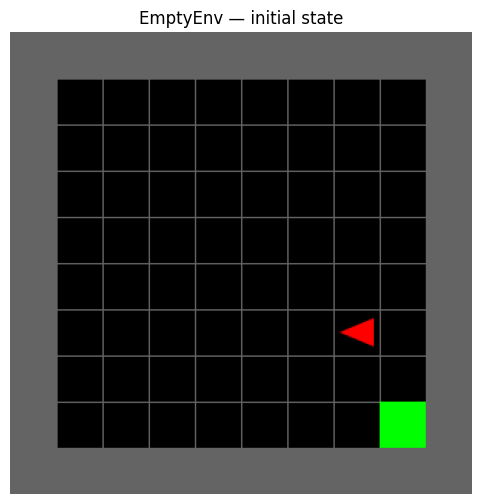

In [233]:
# Sanity-check EmptyEnv: print the API surface, render the initial state,
# and save a short random-action rollout as mp4.
empty_env = EmptyEnv(max_steps=100)
obs, _ = empty_env.reset(seed=0)

print("=== EmptyEnv ===")
print(f"Grid size:        {empty_env.width} x {empty_env.height}")
print(f"Action space:     {empty_env.action_space}")
print(f"Number of actions: {empty_env.action_space.n}")
print(f"Agent position:   {empty_env.agent_pos}")
print(f"Agent direction:  {empty_env.agent_dir}")
print(f"Goal position:    {empty_env.goal_pos}")

plt.imshow(empty_env.render())
plt.title("EmptyEnv — initial state")
plt.axis("off")
plt.show()


In [234]:
video_file = video_path("EmptyEnv_random.mp4")
steps, total_reward = random_rollout_video(empty_env, video_file, max_steps=100, seed=1)
print(f"Random rollout: steps={steps}, total_reward={total_reward:.2f}")
embed_mp4(video_file)


Random rollout: steps=100, total_reward=-10.00


# Environment 2: KeyDoorLavaEnv

**Task.** Pick up the key in the **left room**, open the locked door, cross the lava through a
safe gap, and reach the goal in the **right room**.

| Property | Value |
|----------|-------|
| **Geometry** | |
| Grid size | `10×10` (1-cell outer wall + `8×8` walkable interior) |
| Partition wall | Vertical wall at column 4 — splits the interior into a **left room** (cols 1–3) and a **right room** (cols 5–8) |
| Lava column | Vertical lava at column 7 in the **right room** |
| Safe gaps | Rows 4 and 5 of the lava column — the only safe crossings |
| **Start state (randomised per episode)** | |
| Agent | Random cell in the **left room** (never on the key); random direction in `{0, 1, 2, 3}` |
| Key | One key at a random cell in the **left room** |
| Door | Locked door at a random row of the partition wall |
| Goal | Top-right or bottom-right corner, chosen at random |
| **Termination & reward** | |
| Lava contact | Episode ends immediately, reward `0` |
| Actions | All 7 MiniGrid actions |
| Reward | Sparse: `+1` on goal, `0` otherwise |

**Action subset.** Pick the subset your policy uses (`pickup` and `toggle` matter here, unlike
`EmptyEnv`) and keep it fixed for the run.

**Helper methods / attributes** (use these for state representation and reward shaping):
`env.is_carrying_key()`, `env.is_door_open()`, `env.has_crossed_lava()`, `env.is_on_lava()`,
`env.current_key_pos()` (returns `None` while carried); plus the attributes `env.agent_pos`,
`env.agent_dir`, `env.door_pos`, `env.goal_pos`, `env.partition_col`, `env.lava_col`,
`env.lava_gap_rows`, `env.lava_positions`.

> ⚠️ **Edit policy (KeyDoorLavaEnv).** You may:
> 1. Override `max_steps` at instantiation.
> 2. Scale the goal reward in `step()` (line marked `# you may scale this value`).
> 3. Add reward shaping inside the `# TODO (student): reward shaping` hooks in `__init__` /
>    `reset` / `step`: up to **two** event-based bonuses (e.g. on opening the door), plus an
>    optional small step penalty (which does **not** count toward the two).
>
> ❌ **Not allowed:** changing any other constructor default; any **distance-based** shaping
> (distance to goal/key/door/gap, tracked minimums) — these trivialise the task; any other code
> edits in the class.
>
> A bonus that looks helpful can quietly bias the policy — think about what each event encourages
> *and* what it might unintentionally encourage.

### Quick Test

=== KeyDoorLavaEnv ===
Grid size:               10 x 10
Action space:            Discrete(7)
Number of actions:       7
Agent position:          (1, 1)
Agent direction:         0
Partition column:        x=4
Key position:            (2, 5)
Door position:           (4, 7)
Lava column:             x=7
Lava gap rows:           y=[4, 5]
Lava cells:              [(7, 1), (7, 2), (7, 3), (7, 6), (7, 7), (7, 8)]
Goal position:           (8, 1)
is_carrying_key:         False
is_door_open:            False
has_crossed_lava:        False


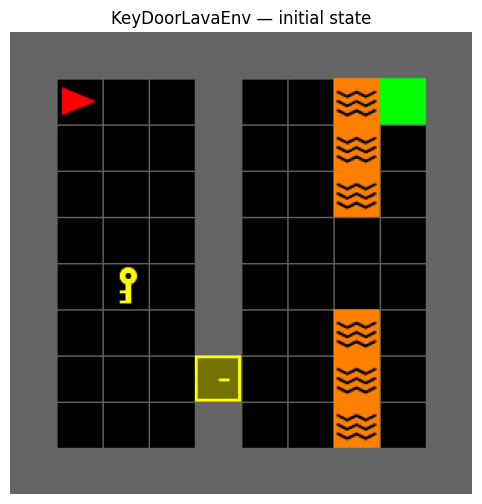

In [235]:
# Sanity-check KeyDoorLavaEnv: print the API surface and helper-method outputs,
# render the initial state, and save a short random-action rollout as mp4.
keydoor_lava_env = KeyDoorLavaEnv(max_steps=100)
obs, _ = keydoor_lava_env.reset(seed=0)
print("=== KeyDoorLavaEnv ===")
print(f"Grid size:               {keydoor_lava_env.width} x {keydoor_lava_env.height}")
print(f"Action space:            {keydoor_lava_env.action_space}")
print(f"Number of actions:       {keydoor_lava_env.action_space.n}")
print(f"Agent position:          {keydoor_lava_env.agent_pos}")
print(f"Agent direction:         {keydoor_lava_env.agent_dir}")
print(f"Partition column:        x={keydoor_lava_env.partition_col}")
print(f"Key position:            {keydoor_lava_env.current_key_pos()}")
print(f"Door position:           {keydoor_lava_env.door_pos}")
print(f"Lava column:             x={keydoor_lava_env.lava_col}")
print(f"Lava gap rows:           y={keydoor_lava_env.lava_gap_rows}")
print(f"Lava cells:              {keydoor_lava_env.lava_positions}")
print(f"Goal position:           {keydoor_lava_env.goal_pos}")
print(f"is_carrying_key:         {keydoor_lava_env.is_carrying_key()}")
print(f"is_door_open:            {keydoor_lava_env.is_door_open()}")
print(f"has_crossed_lava:        {keydoor_lava_env.has_crossed_lava()}")

plt.imshow(keydoor_lava_env.render())
plt.title("KeyDoorLavaEnv — initial state")
plt.axis("off")
plt.show()


In [236]:
video_file = video_path("KeyDoorLavaEnv_random.mp4")
steps, total_reward = random_rollout_video(keydoor_lava_env, video_file, max_steps=100, seed=1)
print(f"Random rollout: steps={steps}, total_reward={total_reward:.2f}")
embed_mp4(video_file)


Random rollout: steps=100, total_reward=-50.00


# Your Code Below

Everything below this divider is yours to fill in. Add as many cells as you need, choose your own
structure, and make sure every deliverable required by the spec is clearly identifiable.

In [237]:
# ── Type aliases ────────────────────────────────────────────────────────────
# EmptyEnv        → (x, y, dir)
# KeyDoorLavaEnv  → (x, y, dir, is_carrying_key, is_door_open, has_crossed_lava)
from typing import TypeAlias

State: TypeAlias = tuple[int, ...]
EpisodeStep: TypeAlias = tuple[State, int, float]
Episode: TypeAlias = list[EpisodeStep]
StateAction: TypeAlias = tuple[State, int]

In [238]:
def _detect_actions(env) -> tuple[int, ...]:
    """
    Infer the relevant action set from the environment class name.
 
    EmptyEnv        → (0, 1, 2)          left / right / forward
    KeyDoorLavaEnv  → (0, 1, 2, 3, 5)   left / right / forward / pickup / toggle
    Fallback        → all actions in env.action_space
    """
    name = type(env).__name__
    if "KeyDoor" in name or "Lava" in name:
        return (0, 1, 2, 3, 5)
    if "Empty" in name:
        return (0, 1, 2)
    return tuple(range(env.action_space.n))
 

In [239]:
# ── Base class ───────────────────────────────────────────────────────────────
class TabularRLAgent(ABC):
    """
    Abstract base for tabular RL agents (Monte Carlo, SARSA, Q-Learning).
 
    Subclasses must implement:
        - update_q_table(state, action, reward, next_state)  ← the core learning rule
        - train(episodes, max_steps)                         ← the training loop
 
    Everything else (state encoding, action selection, evaluation, logging,
    epsilon decay) lives here and is shared by all three algorithms.
    """
 
    def __init__(
        self,
        env,
        *,
        gamma: float = 0.99,
        epsilon: float = 1.0,
        epsilon_min: float = 0.01,
        epsilon_decay: float = 0.995,
        actions: tuple[int, ...] | None = None,
    ) -> None:
        """
        Parameters
        ----------
        env           : MiniGrid environment instance (EmptyEnv or KeyDoorLavaEnv).
        gamma         : Discount factor.
        epsilon       : Initial exploration rate for ε-greedy policy.
        epsilon_min   : Floor for ε after decay.
        epsilon_decay : Multiplicative decay applied to ε after each episode.
        actions       : Tuple of action integers the policy may choose from.
                        If None (default), auto-detected from the environment class name:
                          EmptyEnv        → (0, 1, 2)
                          KeyDoorLavaEnv  → (0, 1, 2, 3, 5)
        """
        self.env = env
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.actions = actions if actions is not None else _detect_actions(env)
 
        # Q-table: (State, action) → float
        self.q_table: dict[StateAction, float] = {}
 
        # ── Training history (populated by train()) ──────────────────────────
        self.history: dict[str, list] = {
            "episode_rewards":  [],   # total reward per episode
            "episode_steps":    [],   # steps taken per episode
            "episode_success":  [],   # 1 if goal reached, 0 otherwise
        }
 
    # ── State encoding ───────────────────────────────────────────────────────
 
    def get_state(self) -> State:
        """
        Refined Awareness State Representation:
        (ax, ay, ad, milestone, dx, dy)
        - ax, ay: Agent position (for spatial memory)
        - ad: Agent direction
        - milestone: 0:Key, 1:Door, 2:Gap, 3:Goal
        - dx, dy: Relative offset to current target
        """
        ax, ay = self.env.agent_pos
        ad = int(self.env.agent_dir)
 
        name = type(self.env).__name__
        if "KeyDoor" in name or "Lava" in name:
            if not self.env.is_carrying_key():
                milestone, target = 0, self.env.current_key_pos()
            elif not self.env.is_door_open():
                milestone, target = 1, self.env.door_pos
            elif not self.env.has_crossed_lava():
                milestone = 2
                goal_y = self.env.goal_pos[1]
                best_gap = min(self.env.lava_gap_rows, key=lambda r: abs(r - goal_y))
                target = (self.env.lava_col, best_gap)
            else:
                milestone, target = 3, self.env.goal_pos
            
            tx, ty = target if target else (0, 0)
            dx, dy = int(tx - ax), int(ty - ay)
            return (int(ax), int(ay), ad, milestone, dx, dy)
        
        return (int(ax), int(ay), ad)
 
    # ── Core learning rule (must be implemented by each algorithm) ───────────
 
    @abstractmethod
    def update_q_table(
        self,
        state: State,
        action: int,
        reward: float,
        next_state: State | None,
    ) -> None:
        """
        Update Q(state, action) using one piece of experience.
 
        Parameters
        ----------
        state      : State in which the action was taken.
        action     : Action taken.
        reward     : Reward received (or MC return G_t for Monte Carlo).
        next_state : Resulting state (None for Monte Carlo / terminal steps).
        """
 
    # ── Training loop (must be implemented by each algorithm) ────────────────
 
    @abstractmethod
    def train(self, episodes: int, max_steps: int) -> None:
        """
        Run the full training procedure for `episodes` episodes.
 
        Each implementation should:
          1. Reset the env and encode the initial state.
          2. Interact with the env (full episode for MC, step-by-step for TD).
          3. Call self.update_q_table(...) with appropriate arguments.
          4. Call self._log_episode(total_reward, steps, success) at the end.
          5. Call self._decay_epsilon() at the end of each episode.
        """
 
    # ── Policy ───────────────────────────────────────────────────────────────
 
    def policy(self, state: State) -> int:
        """Greedy policy for inference — ties broken randomly."""
        q_values = [self.q_table.get((state, a), 0.0) for a in self.actions]
        max_q = max(q_values)
        best = [a for a, q in zip(self.actions, q_values) if q == max_q]
        return int(random.choice(best))
 
    def _select_action(self, state: State) -> int:
        """ε-greedy action selection used during training."""
        if random.random() < self.epsilon:
            return int(random.choice(self.actions))
        return self.policy(state)
 
    # ── Epsilon decay ─────────────────────────────────────────────────────────
 
    def _decay_epsilon(self) -> None:
        """Apply multiplicative decay; clamp to epsilon_min."""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
 
    # ── Logging ──────────────────────────────────────────────────────────────
 
    def _log_episode(self, total_reward: float, steps: int, success: bool) -> None:
        """Append one episode's metrics to self.history."""
        self.history["episode_rewards"].append(total_reward)
        self.history["episode_steps"].append(steps)
        self.history["episode_success"].append(int(success))
 
    # ── Evaluation ───────────────────────────────────────────────────────────
 
    def evaluate(self, episodes: int = 100, max_steps: int = 500) -> dict:
        """
        Run the greedy policy (ε = 0) for `episodes` episodes.
 
        Returns
        -------
        dict with keys:
            mean_reward   : average total reward
            mean_steps    : average steps to termination
            success_rate  : fraction of episodes where goal was reached
        """
        rewards, steps_list, successes = [], [], []
 
        for _ in range(episodes):
            self.env.reset()
            state = self.get_state()
            total_reward, steps, success = 0.0, 0, False
 
            for _ in range(max_steps):
                action = self.policy(state)          # greedy — no exploration
                _, reward, terminated, truncated, _ = self.env.step(action)
                state = self.get_state()
                total_reward += reward
                steps += 1
                if terminated:
                    success = True
                if terminated or truncated:
                    break
 
            rewards.append(total_reward)
            steps_list.append(steps)
            successes.append(int(success))
 
        return {
            "mean_reward":  float(np.mean(rewards)),
            "mean_steps":   float(np.mean(steps_list)),
            "success_rate": float(np.mean(successes)),
        }
 
    # ── Convenience ──────────────────────────────────────────────────────────
 
    def q_table_size(self) -> int:
        """Number of (state, action) pairs currently in the Q-table."""
        return len(self.q_table)
 
    def __repr__(self) -> str:
        return (
            f"{self.__class__.__name__}("
            f"γ={self.gamma}, ε={self.epsilon:.4f}, "
            f"actions={self.actions}, "
            f"q_entries={self.q_table_size()})"
        )
 

In [240]:
class MonteCarlo(TabularRLAgent):
    """First-visit Monte Carlo control with ε-greedy exploration."""
 
    def __init__(self, env, *, alpha: float = 0.05, **kwargs) -> None:
        super().__init__(env, **kwargs)
        self.alpha = alpha # Constant learning rate for non-stationary policies
 
    def train(self, episodes: int, max_steps: int) -> None:
        for _ in tqdm(range(episodes), desc="Monte Carlo"):
            self.env.reset()
            state = self.get_state()
            episode: Episode = []
            total_reward = 0.0
            success = False
 
            for _ in range(max_steps):
                action = self._select_action(state)
                _, reward, terminated, truncated, _ = self.env.step(action)
                episode.append((state, action, float(reward)))
                next_state = None if (terminated or truncated) else self.get_state()

                state = next_state

                total_reward += reward
                success = terminated

                if terminated or truncated:
                    break
 
            self._update_from_episode(episode)
            self._log_episode(total_reward, len(episode), success)
            self._decay_epsilon()
 
    def _update_from_episode(self, episode: Episode) -> None:
        """First-visit MC: update each (state, action) once per episode."""
        G = 0.0
        visited: set[StateAction] = set()
        for state, action, reward in reversed(episode):
            G = self.gamma * G + reward
            sa = (state, action)
            if sa in visited:
                continue
            visited.add(sa)
            self.update_q_table(state, action, G, None)
 
    def update_q_table(
        self,
        state: State,
        action: int,
        reward: float,          # G_t (the MC return)
        next_state,             # unused for MC
    ) -> None:
        """Exponential moving average: Q ← Q + alpha * (G - Q)."""
        key = (state, action)
        old_q = self.q_table.get(key, 0.0)
        self.q_table[key] = old_q + self.alpha * (reward - old_q)
 
 

In [241]:
class QLearning(TabularRLAgent):
    """Off-policy TD(0) — Q-Learning."""
 
    def __init__(self, env, *, alpha: float = 0.1, **kwargs) -> None:
        super().__init__(env, **kwargs)
        self.alpha = alpha
 
    def train(self, episodes: int, max_steps: int) -> None:
        for _ in tqdm(range(episodes), desc="Q-Learning"):
            self.env.reset()
            state = self.get_state()
            total_reward, steps, success = 0.0, 0, False
 
            for _ in range(max_steps):
                action = self._select_action(state)
                _, reward, terminated, truncated, _ = self.env.step(action)
                next_state = None if (terminated or truncated) else self.get_state()
 
                self.update_q_table(state, action, reward, next_state)
 
                total_reward += reward
                steps += 1
                state = next_state
                if terminated:
                    success = True
                if terminated or truncated:
                    break
 
            self._log_episode(total_reward, steps, success)
            self._decay_epsilon()
 
    def update_q_table(
        self,
        state: State,
        action: int,
        reward: float,
        next_state: State | None,
        **_,                    # absorbs extra kwargs (e.g. next_action) gracefully
    ) -> None:
        """Q-Learning update: Q(s,a) ← Q(s,a) + α[r + γ·max_a'Q(s',a') − Q(s,a)]"""
        key = (state, action)
        current_q = self.q_table.get(key, 0.0)
 
        if next_state is None:
            max_next_q = 0.0
        else:
            max_next_q = max(
                self.q_table.get((next_state, a), 0.0) for a in self.actions
            )
 
        td_target = reward + self.gamma * max_next_q
        self.q_table[key] = current_q + self.alpha * (td_target - current_q)
 


In [242]:
class SARSA(TabularRLAgent):
    """On-policy TD(0) — SARSA."""
 
    def __init__(self, env, *, alpha: float = 0.1, **kwargs) -> None:
        super().__init__(env, **kwargs)
        self.alpha = alpha      # learning rate
 
    def train(self, episodes: int, max_steps: int) -> None:
        for _ in tqdm(range(episodes), desc="SARSA"):
            self.env.reset()
            state = self.get_state()
            action = self._select_action(state)
            total_reward, steps, success = 0.0, 0, False
 
            for _ in range(max_steps):
                _, reward, terminated, truncated, _ = self.env.step(action)
                done = terminated or truncated
 
                if done:
                    self.update_q_table(state, action, reward, None, None)
                else:
                    next_state = self.get_state()
                    next_action = self._select_action(next_state)   # ← on-policy
                    self.update_q_table(state, action, reward, next_state, next_action)
                    state, action = next_state, next_action
 
                total_reward += reward
                steps += 1
                if terminated:
                    success = True
                if terminated or truncated:
                    break
 
            self._log_episode(total_reward, steps, success)
            self._decay_epsilon()
 
    def update_q_table(
        self,
        state: State,
        action: int,
        reward: float,
        next_state: State | None,
        next_action: int | None = None,   # required for SARSA
    ) -> None:
        """SARSA update: Q(s,a) ← Q(s,a) + α[r + γ·Q(s',a') − Q(s,a)]"""
        key = (state, action)
        current_q = self.q_table.get(key, 0.0)
 
        if next_state is None or next_action is None:
            next_q = 0.0
        else:
            next_q = self.q_table.get((next_state, next_action), 0.0)
 
        td_target = reward + self.gamma * next_q
        self.q_table[key] = current_q + self.alpha * (td_target - current_q)


In [243]:
def greedy_rollout_video(
    agent,
    env,
    filename: str,
    max_steps: int = 100,
    fps: int = 10,
    seed: int | None = None,
):
    """Run one greedy-policy episode and save it as mp4. Returns (steps, total_reward, reached_goal)."""
    env.reset(seed=seed)
    state = agent.get_state()
    total_reward = 0.0
    reached_goal = False
    steps = 0
    with imageio.get_writer(filename, fps=fps) as video:
        video.append_data(env.render())
        for steps in range(1, max_steps + 1):
            action = agent.policy(state)
            _, reward, terminated, truncated, _ = env.step(action)
            total_reward += float(reward)
            state = agent.get_state()
            video.append_data(env.render())
            if terminated:
                reached_goal = True
            if terminated or truncated:
                break
    return steps, total_reward, reached_goal



In [244]:
#Empty Env Default Parameters
MAX_STEPS_EMPTY_ENV = 100
TRAIN_EPISODES_EMPTY_ENV = 2000
EVAL_EPISODES_EMPTY_ENV = 100
PLOT_WINDOW_EMPTY_ENV = 50  # rolling-average window for training curves

#Key Door Env Default Parameters
MAX_STEPS_KEY_DOOR_ENV = 500
TRAIN_EPISODES_KEY_DOOR_ENV = 5000
EVAL_EPISODES_KEY_DOOR_ENV = 500
PLOT_WINDOW_KEY_DOOR_ENV = 50  # rolling-average window for training curves


In [245]:
emptyenv_agents: dict[str, TabularRLAgent] = {}
lava_and_key_env_agents: dict[str, TabularRLAgent] = {}

def _rolling_mean(values: np.ndarray, window: int) -> np.ndarray:
    kernel = np.ones(window) / window
    return np.convolve(values, kernel, mode="valid")


def plot_training_curves(
    agent: TabularRLAgent,
    algorithm: str,
    env_name: str = "EmptyEnv",
    window: int = PLOT_WINDOW_EMPTY_ENV,
) -> None:
    """Plot reward, steps, and success rate vs training episode."""
    rewards = np.asarray(agent.history["episode_rewards"], dtype=float)
    steps = np.asarray(agent.history["episode_steps"], dtype=float)
    success = np.asarray(agent.history["episode_success"], dtype=float)
    episodes = np.arange(1, len(rewards) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle(f"{algorithm} — {env_name} (training)", fontsize=13)

    for ax, values, ylabel, title, color in zip(
        axes,
        (rewards, steps, success),
        ("Reward", "Steps", "Success rate"),
        ("Reward per episode", "Steps per episode", "Success per episode"),
        ("C0", "C1", "C2"),
    ):
        ax.plot(episodes, values, alpha=0.25, linewidth=0.8, color=color)
        if len(episodes) >= window:
            smoothed = _rolling_mean(values, window)
            ax.plot(
                episodes[window - 1 :],
                smoothed,
                linewidth=2,
                color=color,
                label=f"{window}-episode avg",
            )
            ax.legend(loc="best", fontsize=8)
        ax.set_xlabel("Training episode")
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        if title.startswith("Success"):
            ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()
    plt.savefig(plot_image_path(f"{algorithm}_{env_name}_training_curves.png"))

BEST_AGENT_KWARGS = dict(
    gamma         = 0.95,
    epsilon       = 1.0,
    epsilon_min   = 0.05,
    epsilon_decay = 0.999,
)


In [246]:

def initialize_q_table(agent):
    """
    'Golden Balance' Initialization:
    Initialize Q-values to -Manhattan Distance to current target.
    This ensures the agent always prefers states closer to the next milestone.
    """
    w, h = agent.env.width, agent.env.height
    
    if "Empty" in type(agent.env).__name__:
        gx, gy = agent.env.goal_pos
        for x in range(1, w - 1):
            for y in range(1, h - 1):
                for d in range(4):
                    state = (x, y, d)
                    dist = abs(x - gx) + abs(y - gy)
                    for a in agent.actions:
                        agent.q_table[(state, a)] = -float(dist)
        return

    if "KeyDoor" in type(agent.env).__name__:
        # Targets (dx, dy) are relative offsets to the objective.
        # We initialize valid Agent (ax, ay) and Relative (dx, dy) pairs.
        for milestone in range(4):
            for ax in range(1, w - 1):
                for ay in range(1, h - 1):
                    for ad in range(4):
                        # Use realistic offset ranges for a 10x10 grid
                        for dx in range(-(w-1), w):
                            for dy in range(-(h-1), h):
                                state = (ax, ay, ad, milestone, dx, dy)
                                dist = abs(dx) + abs(dy)
                                for a in agent.actions:
                                    val = -float(dist)
                                    # Directional bias: Moving toward target is better
                                    if a == 2: # Forward
                                        if (ad == 0 and dx > 0) or (ad == 1 and dy > 0) or \
                                           (ad == 2 and dx < 0) or (ad == 3 and dy < 0):
                                            val += 0.5
                                    agent.q_table[(state, a)] = val

def plot_comparison(agents, labels, window=PLOT_WINDOW_EMPTY_ENV):
    _, axes = plt.subplots(1, 3, figsize=(15, 4))
    metrics = ["episode_rewards", "episode_steps", "episode_success"]
    ylabels = ["Reward", "Steps", "Success Rate"]
    titles = ["Reward per Episode", "Steps per Episode", "Success Rate"]
    
    for i, metric in enumerate(metrics):
        for agent, label in zip(agents, labels):
            values = np.asarray(agent.history[metric], dtype=float)
            if len(values) >= window:
                smoothed = _rolling_mean(values, window)
                axes[i].plot(np.arange(window - 1, len(values)), smoothed, label=label)
        axes[i].set_xlabel("Episode")
        axes[i].set_ylabel(ylabels[i])
        axes[i].set_title(titles[i])
        axes[i].legend()
    plt.tight_layout()
    plt.show()
    plt.savefig(plot_image_path(f"comparison_{'_'.join(labels)}.png"))

## EmptyEnv — Training & Inference Results

1. **Random hyperparameter search** — sample configs, score with greedy eval, compare all trials.
2. **Final training** — one cell per algorithm using the best hyperparameters.
3. **Inference** — table + bar chart comparing algorithms.

### Monte Carlo — reward search & final training

Search over `EmptyEnv.step_fn` rewards (goal bonus, per-step penalty, timeout penalty), then train with the best config and `BEST_AGENT_KWARGS`.

Training MC Agent WITH initialization (and reduced exploration)...


Monte Carlo: 100%|██████████| 2000/2000 [00:03<00:00, 549.46it/s] 


Training MC Agent WITHOUT initialization...


Monte Carlo: 100%|██████████| 2000/2000 [00:03<00:00, 510.72it/s] 


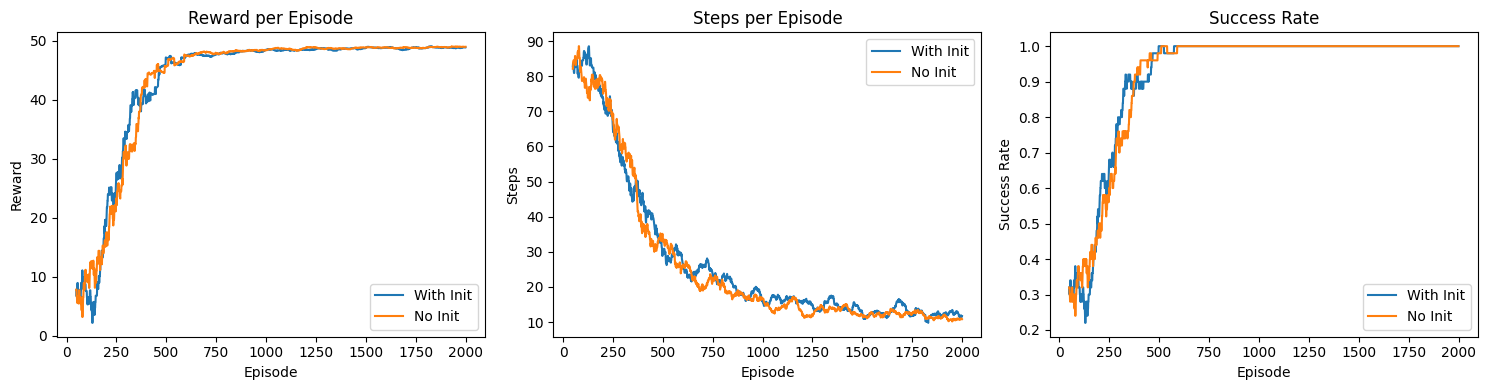

<Figure size 800x600 with 0 Axes>

In [247]:

print("Training MC Agent WITH initialization (and reduced exploration)...")
mc_env_init   = EmptyEnv(max_steps=MAX_STEPS_EMPTY_ENV)
init_kwargs   = BEST_AGENT_KWARGS.copy()
mc_agent_init = MonteCarlo(mc_env_init, **init_kwargs)
initialize_q_table(mc_agent_init)
mc_agent_init.train(episodes=TRAIN_EPISODES_EMPTY_ENV, max_steps=MAX_STEPS_EMPTY_ENV)

print("Training MC Agent WITHOUT initialization...")
mc_env_no_init   = EmptyEnv(max_steps=MAX_STEPS_EMPTY_ENV)
mc_agent_no_init = MonteCarlo(mc_env_no_init, **BEST_AGENT_KWARGS)
mc_agent_no_init.train(episodes=TRAIN_EPISODES_EMPTY_ENV, max_steps=MAX_STEPS_EMPTY_ENV)

emptyenv_agents["Monte Carlo"] = mc_agent_no_init
plot_comparison([mc_agent_init, mc_agent_no_init], ["With Init", "No Init"])

In [248]:
print("=== Monte Carlo (EmptyEnv): Trained Agent performance ===")
video_file = video_path("EmptyEnv_MC_trained.mp4")
steps, reward, success = greedy_rollout_video(mc_agent_init, mc_env_init, video_file, max_steps=100)
print(f"Steps: {steps}, Total Reward: {reward:.2f}, Reached Goal: {success}")
embed_mp4(video_file)

=== Monte Carlo (EmptyEnv): Trained Agent performance ===
Steps: 13, Total Reward: 48.80, Reached Goal: True


### Q-Learning

Q-Learning: 100%|██████████| 2000/2000 [00:03<00:00, 562.01it/s] 


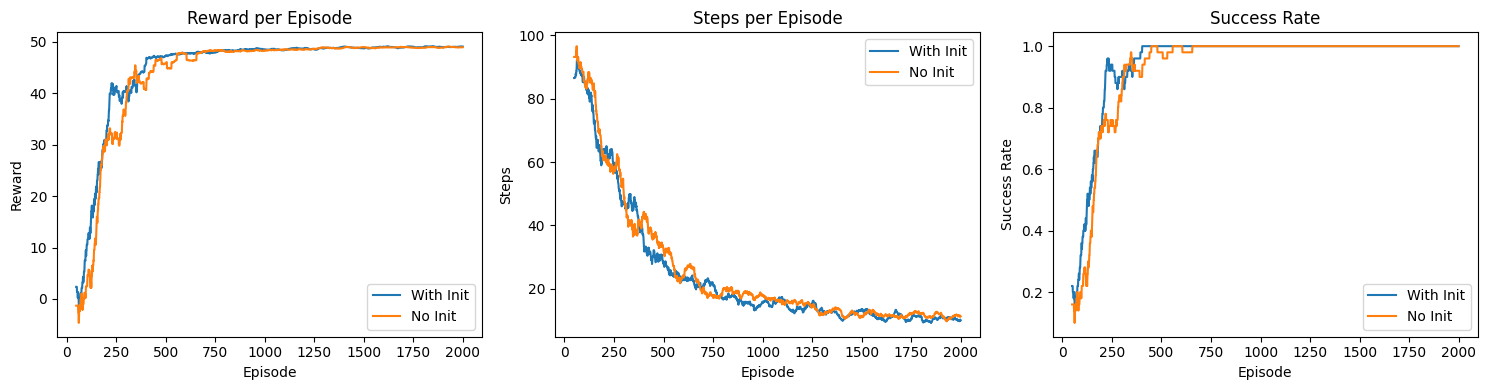

<Figure size 800x600 with 0 Axes>

In [249]:
TD_KWARGS = dict(**BEST_AGENT_KWARGS, alpha=0.1)


ql_env_init = EmptyEnv(max_steps=MAX_STEPS_EMPTY_ENV)
ql_init_kwargs = TD_KWARGS.copy()
ql_agent_init = QLearning(ql_env_init, **ql_init_kwargs)
initialize_q_table(ql_agent_init)
ql_agent_init.train(episodes=TRAIN_EPISODES_EMPTY_ENV, max_steps=MAX_STEPS_EMPTY_ENV)

ql_env_no_init = EmptyEnv(max_steps=MAX_STEPS_EMPTY_ENV)
ql_agent_no_init = QLearning(ql_env_no_init, **TD_KWARGS)
ql_agent_no_init.train(episodes=TRAIN_EPISODES_EMPTY_ENV, max_steps=MAX_STEPS_EMPTY_ENV)

emptyenv_agents["Q-Learning"] = ql_agent_init
plot_comparison([ql_agent_init, ql_agent_no_init], ["With Init", "No Init"])

In [250]:
print("=== Q-Learning (EmptyEnv): Trained Agent performance ===")
video_file = video_path("EmptyEnv_QL_trained.mp4")
steps, reward, success = greedy_rollout_video(ql_agent_init, ql_env_init, video_file, max_steps=100, seed=42)
print(f"Steps: {steps}, Total Reward: {reward:.2f}, Reached Goal: {success}")
embed_mp4(video_file)

=== Q-Learning (EmptyEnv): Trained Agent performance ===
Steps: 10, Total Reward: 49.10, Reached Goal: True


### SARSA

SARSA: 100%|██████████| 2000/2000 [00:03<00:00, 535.66it/s] 


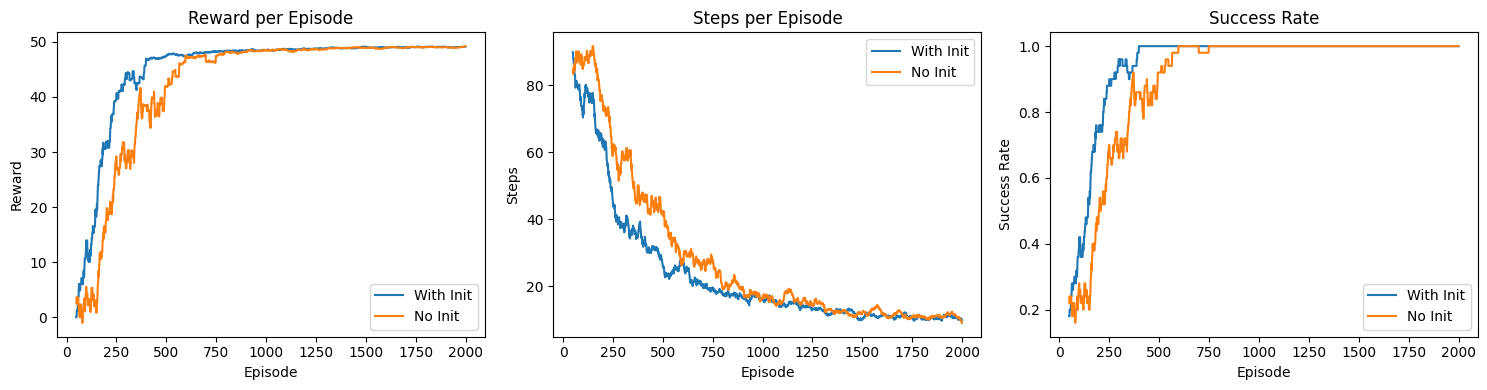

<Figure size 800x600 with 0 Axes>

In [251]:
sarsa_env_init = EmptyEnv(max_steps=MAX_STEPS_EMPTY_ENV)
sarsa_init_kwargs = TD_KWARGS.copy()
sarsa_agent_init = SARSA(sarsa_env_init, **sarsa_init_kwargs)
initialize_q_table(sarsa_agent_init)
sarsa_agent_init.train(episodes=TRAIN_EPISODES_EMPTY_ENV, max_steps=MAX_STEPS_EMPTY_ENV)

sarsa_env_no_init = EmptyEnv(max_steps=MAX_STEPS_EMPTY_ENV)
sarsa_agent_no_init = SARSA(sarsa_env_no_init, **TD_KWARGS)
sarsa_agent_no_init.train(episodes=TRAIN_EPISODES_EMPTY_ENV, max_steps=MAX_STEPS_EMPTY_ENV)

emptyenv_agents["SARSA"] = sarsa_agent_init
plot_comparison([sarsa_agent_init, sarsa_agent_no_init], ["With Init", "No Init"])

In [252]:
print("=== SARSA (EmptyEnv): Trained Agent performance ===")
video_file = video_path("EmptyEnv_SARSA_trained.mp4")
steps, reward, success = greedy_rollout_video(sarsa_agent_init, sarsa_env_init, video_file, max_steps=100, seed=42)
print(f"Steps: {steps}, Total Reward: {reward:.2f}, Reached Goal: {success}")
embed_mp4(video_file)

=== SARSA (EmptyEnv): Trained Agent performance ===
Steps: 10, Total Reward: 49.10, Reached Goal: True


### EmptyEnv — Inference Results (greedy policy)

Greedy evaluation (`agent.evaluate`, no exploration) over `EVAL_EPISODES_EMPTY_ENV` episodes.

=== EmptyEnv inference (100 greedy episodes each) ===

Algorithm    Mean reward  Mean steps  Success rate
-----------  -----------  ----------  ------------
Monte Carlo  48.58        10.2        99.0%       
Q-Learning   49.23        8.7         100.0%      
SARSA        49.26        8.4         100.0%      


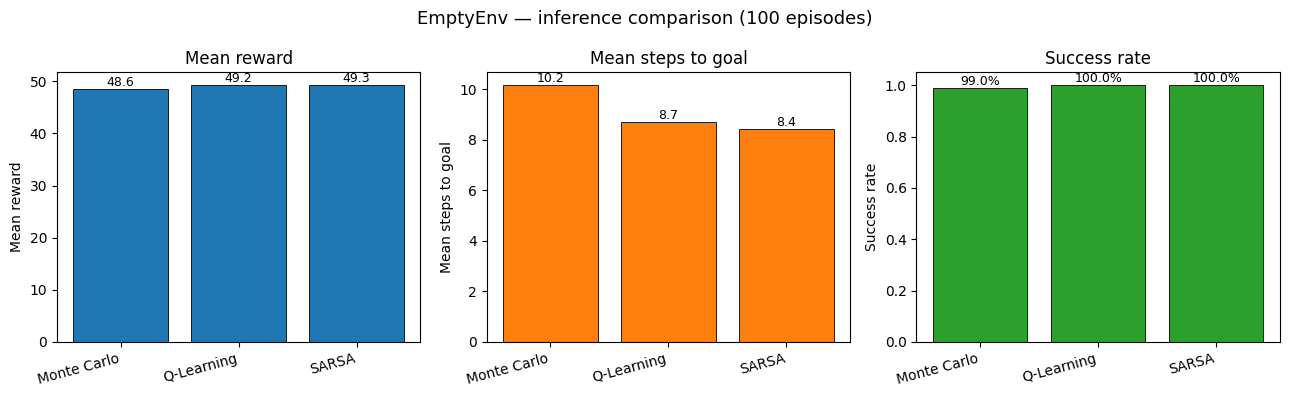

<Figure size 800x600 with 0 Axes>

In [253]:
emptyenv_inference: dict[str, dict[str, float]] = {}
for name, agent in emptyenv_agents.items():
    emptyenv_inference[name] = agent.evaluate(
        episodes=EVAL_EPISODES_EMPTY_ENV, max_steps=MAX_STEPS_EMPTY_ENV
    )

# ── Summary table ────────────────────────────────────────────────────────────
headers = ["Algorithm", "Mean reward", "Mean steps", "Success rate"]
rows = [
    [
        name,
        f"{m['mean_reward']:.2f}",
        f"{m['mean_steps']:.1f}",
        f"{m['success_rate']:.1%}",
    ]
    for name, m in emptyenv_inference.items()
]

print(f"=== EmptyEnv inference ({EVAL_EPISODES_EMPTY_ENV} greedy episodes each) ===\n")
col_widths = [
    max(len(headers[i]), max(len(row[i]) for row in rows))
    for i in range(len(headers))
]
fmt = "  ".join(f"{{:{w}}}" for w in col_widths)
print(fmt.format(*headers))
print(fmt.format(*["-" * w for w in col_widths]))
for row in rows:
    print(fmt.format(*row))

# ── Grouped bar chart ────────────────────────────────────────────────────────
algorithms = list(emptyenv_inference.keys())
metric_specs = [
    ("mean_reward", "Mean reward", "C0"),
    ("mean_steps", "Mean steps to goal", "C1"),
    ("success_rate", "Success rate", "C2"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"EmptyEnv — inference comparison ({EVAL_EPISODES_EMPTY_ENV} episodes)", fontsize=13)

x = np.arange(len(algorithms))
for ax, (key, ylabel, color) in zip(axes, metric_specs):
    values = [emptyenv_inference[alg][key] for alg in algorithms]
    bars = ax.bar(x, values, color=color, edgecolor="black", linewidth=0.6)
    ax.set_xticks(x, algorithms, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    for bar, val in zip(bars, values):
        fmt = f"{val:.1%}" if key == "success_rate" else f"{val:.1f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            fmt,
            ha="center",
            va="bottom",
            fontsize=9,
        )
    if key == "success_rate":
        ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()
plt.savefig(plot_image_path(f"comparison_{'_'.join(algorithms)}.png"))

## Lava And Key Environment 


Training MC Agent on KeyDoorLava (Explicit Params + Init)


Monte Carlo: 100%|██████████| 10000/10000 [01:10<00:00, 142.13it/s]


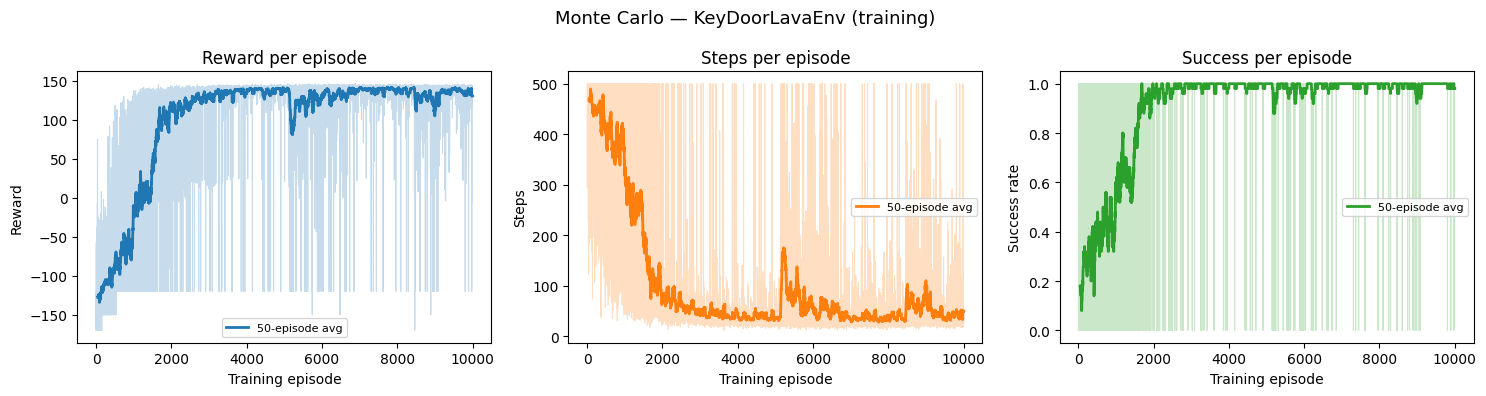

<Figure size 800x600 with 0 Axes>

In [254]:
MAX_STEPS_KEY_DOOR_ENV = 500
TRAIN_EPISODES_KEY_DOOR_ENV = 10_000
EVAL_EPISODES_KEY_DOOR_ENV = 300
PLOT_WINDOW_KEY_DOOR_ENV = 100

lava_and_key_env_agents = {}
print("Training MC Agent on KeyDoorLava (Explicit Params + Init)")
mc_env = KeyDoorLavaEnv(max_steps=MAX_STEPS_KEY_DOOR_ENV)
mc_agent = MonteCarlo(
    mc_env,
    gamma=0.95,
    alpha=0.05,
    epsilon=1.0,
    epsilon_min=0.09,
    epsilon_decay=0.9996
)
initialize_q_table(mc_agent)
mc_agent.train(episodes=TRAIN_EPISODES_KEY_DOOR_ENV, max_steps=MAX_STEPS_KEY_DOOR_ENV)

lava_and_key_env_agents["Monte Carlo"] = mc_agent
plot_training_curves(mc_agent, "Monte Carlo", "KeyDoorLavaEnv")

In [255]:
print("=== Monte Carlo: Trained Agent performance ===")
video_file = video_path("KeyDoorLava_MC_trained.mp4")

steps, reward, success = greedy_rollout_video(mc_agent, mc_env, video_file, max_steps=150)
print(f"Steps: {steps}, Total Reward: {reward:.2f}, Reached Goal: {success}")
embed_mp4(video_file)

=== Monte Carlo: Trained Agent performance ===
Steps: 150, Total Reward: -25.00, Reached Goal: False


Training Q-Learning Agent on KeyDoorLava (Explicit Params + Init)


Q-Learning: 100%|██████████| 10000/10000 [01:03<00:00, 156.66it/s]


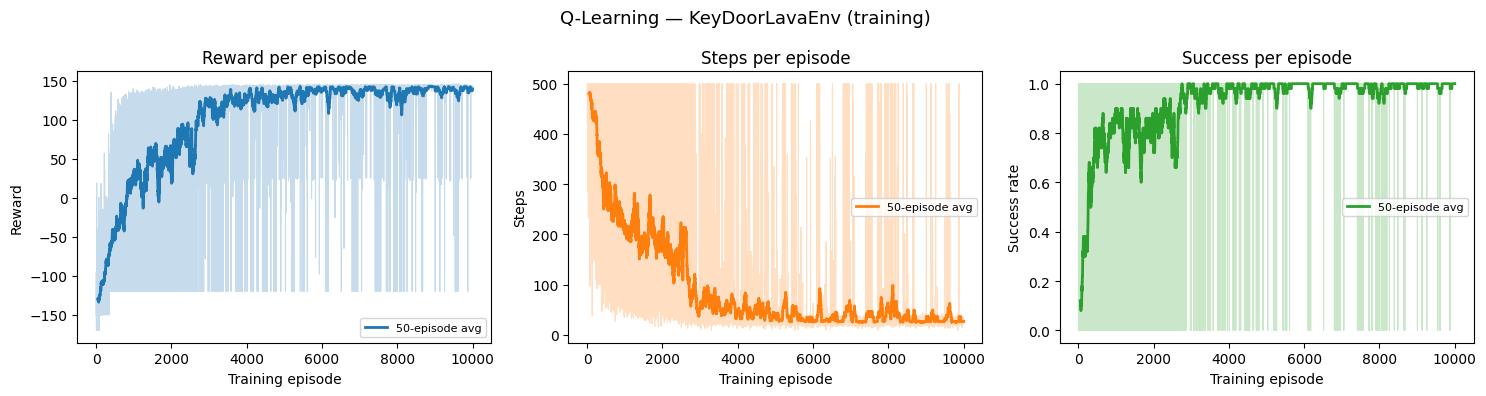

<Figure size 800x600 with 0 Axes>

In [256]:
print("Training Q-Learning Agent on KeyDoorLava (Explicit Params + Init)")
ql_env = KeyDoorLavaEnv(max_steps=MAX_STEPS_KEY_DOOR_ENV)
ql_agent = QLearning(
    ql_env,
    gamma=0.95,
    alpha=0.05,
    epsilon=1.0,
    epsilon_min=0.08,
    epsilon_decay=0.9996
)
initialize_q_table(ql_agent)
ql_agent.train(episodes=TRAIN_EPISODES_KEY_DOOR_ENV, max_steps=MAX_STEPS_KEY_DOOR_ENV)

lava_and_key_env_agents["Q-Learning"] = ql_agent
plot_training_curves(ql_agent, "Q-Learning", "KeyDoorLavaEnv")


In [257]:
print("=== Q-Learning: Trained Agent performance ===")
video_file = video_path("KeyDoorLava_QL_trained.mp4")
steps, reward, success = greedy_rollout_video(ql_agent, ql_env, video_file, max_steps=100)
print(f"Steps: {steps}, Total Reward: {reward:.2f}, Reached Goal: {success}")
embed_mp4(video_file)

=== Q-Learning: Trained Agent performance ===
Steps: 26, Total Reward: 142.50, Reached Goal: True


Training SARSA Agent on KeyDoorLava (Explicit Params + Init)


SARSA: 100%|██████████| 10000/10000 [01:07<00:00, 148.71it/s]


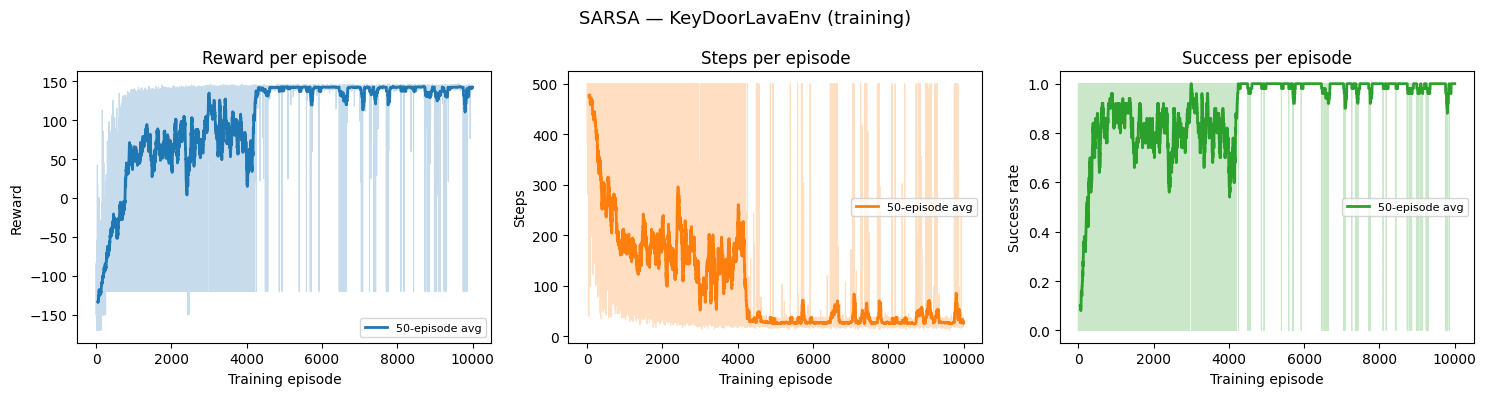

<Figure size 800x600 with 0 Axes>

In [258]:
print("Training SARSA Agent on KeyDoorLava (Explicit Params + Init)")
sarsa_env = KeyDoorLavaEnv(max_steps=MAX_STEPS_KEY_DOOR_ENV)
sarsa_agent = SARSA(
    sarsa_env,
    gamma=0.97,
    alpha=0.1,
    epsilon=1.0,
    epsilon_min=0.07,
    epsilon_decay=0.9995
)
initialize_q_table(sarsa_agent)
sarsa_agent.train(episodes=TRAIN_EPISODES_KEY_DOOR_ENV, max_steps=MAX_STEPS_KEY_DOOR_ENV)

lava_and_key_env_agents["SARSA"] = sarsa_agent
plot_training_curves(sarsa_agent, "SARSA", "KeyDoorLavaEnv")


In [259]:
print("=== SARSA: Trained Agent performance ===")
video_file = video_path("KeyDoorLava_SARSA_trained.mp4")
steps, reward, success = greedy_rollout_video(sarsa_agent, sarsa_env, video_file, max_steps=100)
print(f"Steps: {steps}, Total Reward: {reward:.2f}, Reached Goal: {success}")
embed_mp4(video_file)

=== SARSA: Trained Agent performance ===
Steps: 23, Total Reward: 143.40, Reached Goal: True


=== KeyDoorLavaEnv inference (300 greedy episodes each) ===

Algorithm    Mean reward  Mean steps  Success rate
-----------  -----------  ----------  ------------
Monte Carlo  99.02        94.0        85.7%       
Q-Learning   141.93       26.0        99.7%       
SARSA        143.02       24.3        100.0%      


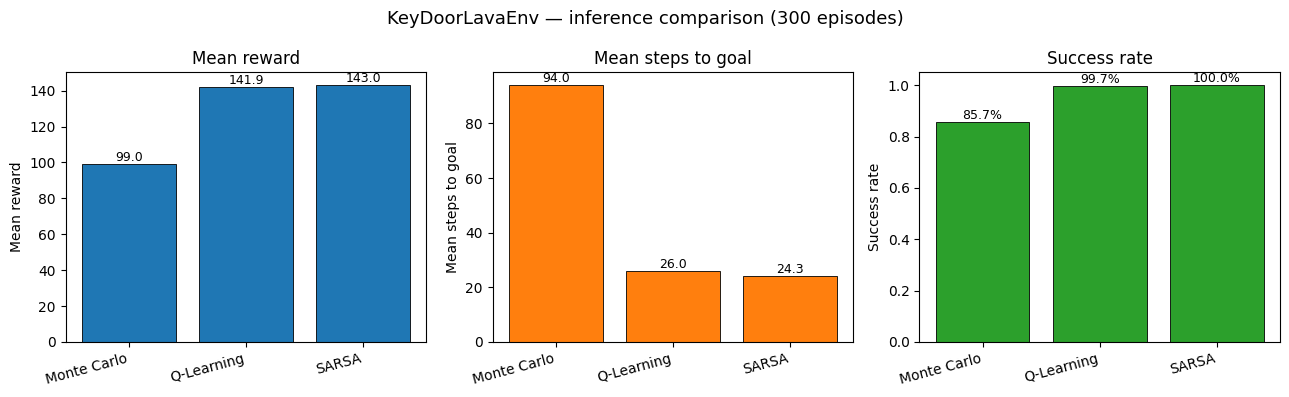

<Figure size 800x600 with 0 Axes>

In [268]:
lava_and_key_env_inference: dict[str, dict[str, float]] = {}
for name, agent in lava_and_key_env_agents.items():
    lava_and_key_env_inference[name] = agent.evaluate(
        episodes=EVAL_EPISODES_KEY_DOOR_ENV, max_steps=MAX_STEPS_KEY_DOOR_ENV
    )

# ── Summary table ────────────────────────────────────────────────────────────
headers = ["Algorithm", "Mean reward", "Mean steps", "Success rate"]
rows = [
    [
        name,
        f"{m['mean_reward']:.2f}",
        f"{m['mean_steps']:.1f}",
        f"{m['success_rate']:.1%}",
    ]
    for name, m in lava_and_key_env_inference.items()
]

print(f"=== KeyDoorLavaEnv inference ({EVAL_EPISODES_KEY_DOOR_ENV} greedy episodes each) ===\n")
col_widths = [
    max(len(headers[i]), max(len(row[i]) for row in rows))
    for i in range(len(headers))
]
fmt = "  ".join(f"{{:{w}}}" for w in col_widths)
print(fmt.format(*headers))
print(fmt.format(*["-" * w for w in col_widths]))
for row in rows:
    print(fmt.format(*row))

# ── Grouped bar chart ────────────────────────────────────────────────────────
algorithms = list(lava_and_key_env_inference.keys())
metric_specs = [
    ("mean_reward", "Mean reward", "C0"),
    ("mean_steps", "Mean steps to goal", "C1"),
    ("success_rate", "Success rate", "C2"),
]

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle(f"KeyDoorLavaEnv — inference comparison ({EVAL_EPISODES_KEY_DOOR_ENV} episodes)", fontsize=13)

x = np.arange(len(algorithms))
for ax, (key, ylabel, color) in zip(axes, metric_specs):
    values = [lava_and_key_env_inference[alg][key] for alg in algorithms]
    bars = ax.bar(x, values, color=color, edgecolor="black", linewidth=0.6)
    ax.set_xticks(x, algorithms, rotation=15, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    for bar, val in zip(bars, values):
        fmt = f"{val:.1%}" if key == "success_rate" else f"{val:.1f}"
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            fmt,
            ha="center",
            va="bottom",
            fontsize=9,
        )
    if key == "success_rate":
        ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()
plt.savefig(plot_image_path(f"comparison_{'_'.join(algorithms)}_key_door_lava.png"))